# Demanda Eléctrica en Texas (ERCOT)

## Objetivo y tarea de pronóstico

Antes de explorar, declaramos **qué vamos a predecir**, porque eso define qué estructura
de los datos importa, qué modelo gana y cómo se evalúa:

- **Variable objetivo:** demanda eléctrica horaria de Texas (`cleaned demand (MW)`).
- **Tarea:** pronóstico **multi-paso a 24 horas** (las próximas 24 horas a partir de la
  última observación disponible). Es el horizonte operativamente relevante para ERCOT
  (programación de generación del día siguiente) y el que mejor expone los ciclos
  diario y semanal que veremos en el EDA.
- **Modelos a comparar:** **ARIMA/SARIMA** (modelo estadístico clásico, exige
  estacionariedad) frente a **LSTM** (red recurrente, captura no linealidades y
  dependencias largas sin supuesto de estacionariedad).
- **Métrica:** MAE y RMSE sobre el horizonte de 24 h, más MAPE para lectura relativa.


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_csv('Data/TEX.csv', parse_dates=['date_time'], na_values=['MISSING', 'EMPTY'])
df = df.set_index('date_time')

df.shape

print(f"Max date: {df.index.max()}")
print(f"Min date: {df.index.min()}")

print(df['cleaned demand (MW)'].describe())
print(df['cleaned demand (MW)'].isna().sum())

Max date: 2024-12-31 23:00:00
Min date: 2020-01-01 00:00:00
count    43848.000000
mean     48247.804643
std      10947.427884
min      27445.000000
25%      40373.750000
50%      45663.500000
75%      53990.250000
max      85559.000000
Name: cleaned demand (MW), dtype: float64
0


## Zona horaria: los timestamps están en **UTC**, no en hora local de Texas

Esto es un problema al analizar todo esto que es importante tocar si es que se manejan temperaturas (por el momento no se tiene planteado eso).
Esto es crítico y fácil de pasar por alto. La demanda horaria de la EIA (fuente de ERCOT)
se publica con marca de tiempo en **UTC**. Si leemos el eje horario de forma literal,
el pico de verano cae cerca de las 22–23 h y el valle cerca de las 10 h, lo cual sería
absurdo en hora local (nadie tiene su máximo de aire acondicionado a las 10 de la noche
ni su mínimo a las 10 de la mañana).

Convertido a **America/Chicago** (hora local de Texas, con horario de verano):
- pico ≈ **17 h (5 PM)** → máximo real de aire acondicionado por la tarde,
- valle ≈ **5 h (5 AM)** → mínimo real de madrugada.

**Para el proyecto:** cuando incorporemos temperatura u
otras covariables climáticas, éstas suelen venir en **hora local**. Mezclar demanda en
UTC con clima en hora local introduce un desfase de **5–6 horas** (oscila porque Texas
cambia a horario de verano) que **destruye la correlación** y nos haría
creer que la temperatura "no sirve". **Decisión:** fijar una sola zona horaria para
todo el pipeline y convertir explícitamente antes de cualquier `merge` temporal.


In [3]:
print(df.index.to_series().diff().value_counts()) 

date_time
0 days 01:00:00    43847
Name: count, dtype: int64


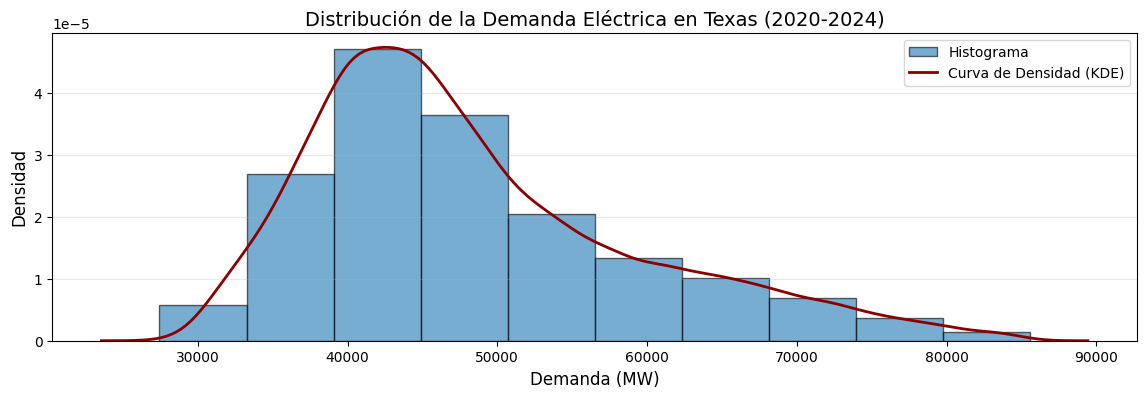

In [4]:
plt.figure(figsize=(14,4))

plt.hist(df['cleaned demand (MW)'], color='#1f77b4', edgecolor='black', density=True, alpha=0.6, label='Histograma')

sns.kdeplot(df['cleaned demand (MW)'], color='darkred', linewidth=2, label='Curva de Densidad (KDE)')

plt.title('Distribución de la Demanda Eléctrica en Texas (2020-2024)', fontsize=14)
plt.xlabel('Demanda (MW)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
from scipy import stats

d = df['cleaned demand (MW)']

print('Estadisticos de forma y dispersión')
print(d.describe().round(1))
print()
print(f'Asimetría (skew):          {stats.skew(d.dropna()):.3f}')
print(f'Curtosis (exceso):         {stats.kurtosis(d.dropna()):.3f}')
print(f'Coef. de variación:        {d.std()/d.mean():.3f}')

# Razón pico/valle del perfil horario promedio
perfil = d.groupby(d.index.hour).mean()
print(f'Razón pico/valle (perfil horario): {perfil.max()/perfil.min():.3f}')


Estadisticos de forma y dispersión
count    43848.0
mean     48247.8
std      10947.4
min      27445.0
25%      40373.8
50%      45663.5
75%      53990.2
max      85559.0
Name: cleaned demand (MW), dtype: float64

Asimetría (skew):          0.922
Curtosis (exceso):         0.386
Coef. de variación:        0.227
Razón pico/valle (perfil horario): 1.371


## Análisis de la distribución

La densidad (KDE) muestra una distribución **unimodal** con moda alrededor de
**~40,000 MW** y **sesgo a la derecha**. La cola larga la aportan los **picos de verano**
de forma sistemática; el invierno contribuye poco a esa cola de manera estructural y
aparece más como **golpes ocasionales de frío** (uno de ellos, Uri).

Cuantificado:

| Estadístico | Valor |
|---|---|
| Media | 48,248 MW |
| Mediana | 45,664 MW |
| Desv. estándar | 10,947 MW |
| **Asimetría (skew)** | **0.92** (sesgo derecho claro) |
| **Curtosis (exceso)** | **0.39** (colas algo más pesadas que la normal) |
| Mínimo | 27,445 MW |
| Máximo | 85,559 MW |

La asimetría positiva (0.92) confirma que la media (48,248) supera a la mediana (45,664):
hay horas de demanda muy alta poco frecuentes pero significativas.

**Decisiones de modelado derivadas:**
- **ARIMA:** el sesgo a la derecha sugiere evaluar una **transformación log o Box-Cox**
  para estabilizar la varianza antes de ajustar.
- **LSTM:** aplicar **escalado** (MinMax o estandarización) ajustado **solo con el
  conjunto de entrenamiento** para no filtrar información del test.


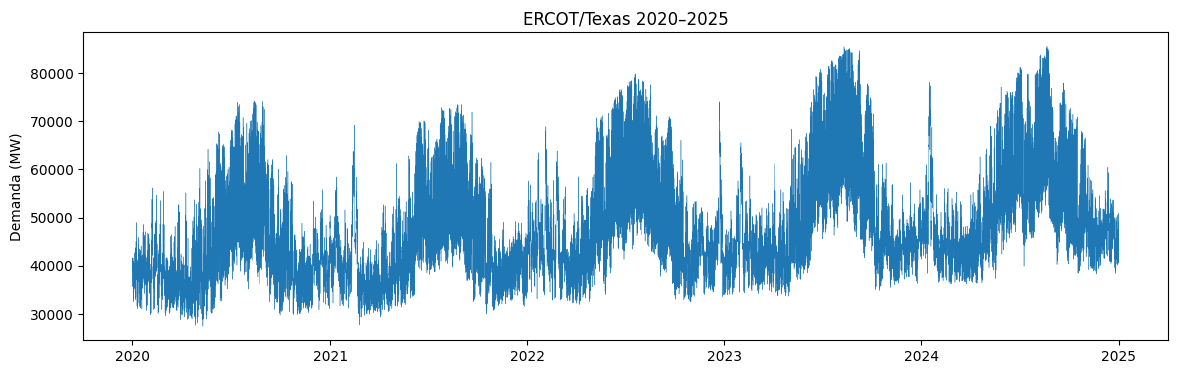

In [6]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['cleaned demand (MW)'], linewidth=0.3)
plt.ylabel('Demanda (MW)'); plt.title('ERCOT/Texas 2020–2025')
plt.show()

## Eventos atípicos y calidad del dato

La serie completa contiene tres situaciones que **no representan demanda normal** y que
hay que **medir** y **convertir en una decisión** antes de modelar:
la tormenta **Uri** (feb-2021), el **confinamiento por COVID** (2020) y las **horas
imputadas** que trae la columna limpia.


In [7]:
# El confinamiento por COVID movió la demanda de forma significativa?
# Comparamos la misma ventana estacional (15-mar a 30-abr) de 2020 vs 2021.
covid_2020 = d['2020-03-15':'2020-04-30'].mean()
base_2021  = d['2021-03-15':'2021-04-30'].mean()
delta = (covid_2020 - base_2021) / base_2021 * 100

print(f'Demanda media 15-mar a 30-abr 2020 (confinamiento): {covid_2020:,.0f} MW')
print(f'Demanda media 15-mar a 30-abr 2021 (referencia):    {base_2021:,.0f} MW')
print(f'Diferencia: {delta:+.2f} %  esto pues dentro del ruido, NO es un efecto significativo')


Demanda media 15-mar a 30-abr 2020 (confinamiento): 37,788 MW
Demanda media 15-mar a 30-abr 2021 (referencia):    38,211 MW
Diferencia: -1.11 %  esto pues dentro del ruido, NO es un efecto significativo


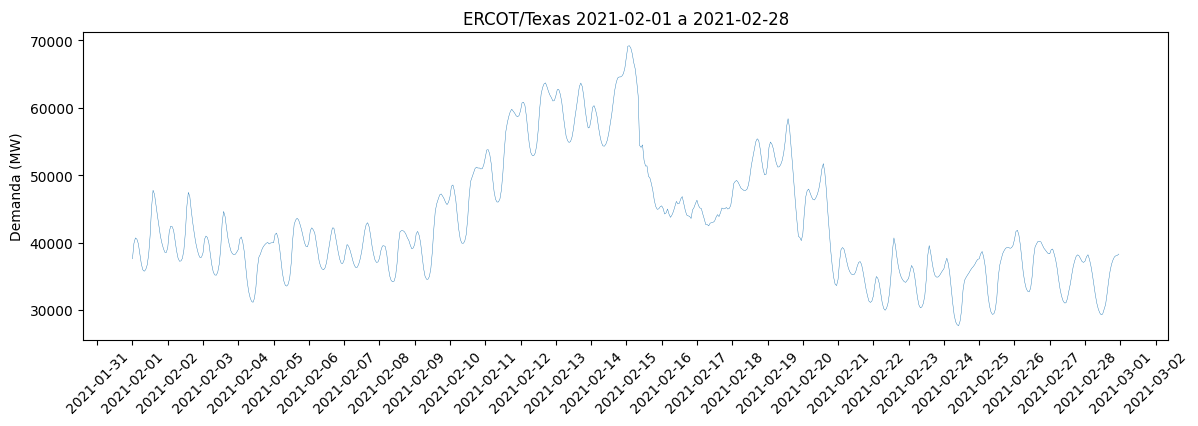

In [8]:

# Acercarse a las dos semanas con hora y todos los dias completos
sub = df.loc['2021-02-01':'2021-02-28', 'cleaned demand (MW)']
plt.figure(figsize=(14,4))
plt.plot(sub.index, sub.values, linewidth=0.3)
plt.ylabel('Demanda (MW)')
plt.title('ERCOT/Texas 2021-02-01 a 2021-02-28')

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()

In [9]:
# Punto 3 — La columna 'raw demand' vs 'cleaned demand': qué se imputó y dónde?
corr = df['raw demand (MW)'] - df['cleaned demand (MW)']
imputado = corr != 0

print(f'Horas con valor imputado/corregido: {imputado.sum()} '
      f'({imputado.mean()*100:.2f}% de la serie)')
print(f'Corrección mediana: {corr[imputado].abs().median():,.0f} MW') # Nota : casi cosmetica
print(f'Corrección máxima:  {corr.abs().max():,.0f} MW')

# Dónde se concentran las imputaciones?
conc = (imputado.groupby([imputado.index.year, imputado.index.month]).sum()
        .sort_values(ascending=False).head(5))
print('\nMeses con más horas imputadas:')
print(conc)

# La corrección más grande NO está en Uri
peor = corr.abs().idxmax()
print(f'\nMayor corrección en: {peor}')
print(df.loc[peor])


Horas con valor imputado/corregido: 549 (1.25% de la serie)
Corrección mediana: 254 MW
Corrección máxima:  45,525 MW

Meses con más horas imputadas:
date_time  date_time
2023       10           73
           3            65
2022       2            29
2021       2            28
2024       11           25
dtype: int64

Mayor corrección en: 2024-08-25 22:00:00
raw demand (MW)        34066
cleaned demand (MW)    79591
Name: 2024-08-25 22:00:00, dtype: int64


### Hallazgos y **decisiones** sobre eventos atípicos y dato no confiable

**Tormenta Uri (feb-2021) — descripción → decisión.** El 9–10 de febrero de 2021 una
tormenta invernal extrema dispara la demanda de calefacción; del 14 al 19 de febrero la
serie **cae bruscamente**. Ese desplome **no es demanda real**: durante el apagón el dato
registrado es **carga servida**, limitada por la falta de generación es **demanda no
satisfecha**, un dato **corrupto para pronóstico**. y pues se toma una
decisión: **esta ventana no representa demanda real → la marcamos con una
variable dummy de evento y la mantenemos FUERA del conjunto de prueba**. (Despues de ver un poco mas, esto es un "quizas")

**COVID-19 (2020) — medido, no afirmado.** El confinamiento (15-mar a 30-abr 2020) dio
una demanda media de **37,788 MW** frente a **38,211 MW** en la misma ventana de 2021:
**−1.1 %**, dentro del ruido. En Texas (mezcla industrial/residencial distinta a otras
regiones) el confinamiento **apenas movió** la demanda. **Decisión:** no tratarlo como
choque estructural; basta con asegurar que 2020 caiga en **entrenamiento**.

**Horas imputadas — la columna que no debíamos ignorar.** El **1.25 % (549 horas)** de la
variable objetivo es **sintético**: lo imputó el algoritmo de limpieza de la fuente. No se
concentran en Uri sino en **octubre 2023 (73 h)** y **marzo 2023 (65 h)**. La corrección
mediana es **254 MW** (casi nadita), pero existe una de **45,525 MW** — un valor crudo
roto (raw ≈ 34,066 → limpio ≈ 79,591). esa corrección máxima **no es de Uri**, ocurre
el **2024-08-25** (pico de verano). **Decisión:** conservar una bandera `es_imputado` y, si
el conjunto de prueba cae sobre horas imputadas, reportarlo — evaluar un modelo contra
horas inventadas es calificarlo contra ficción.


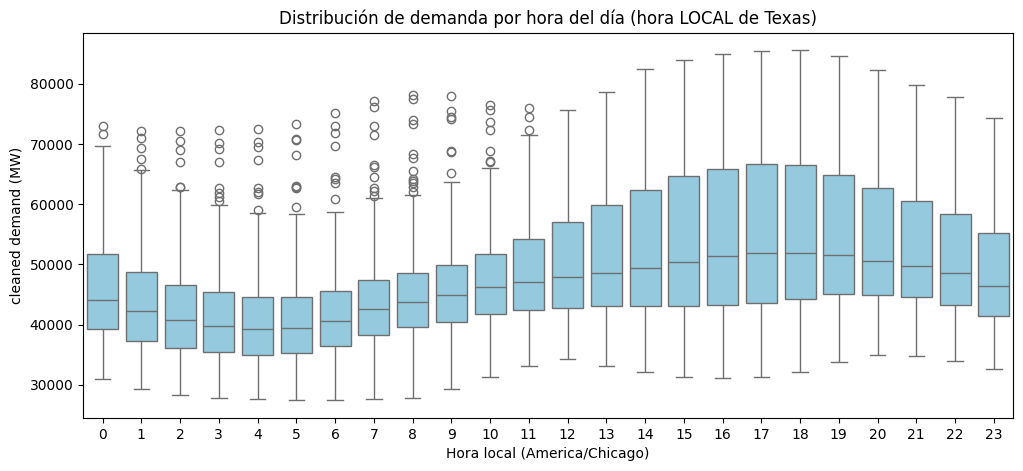

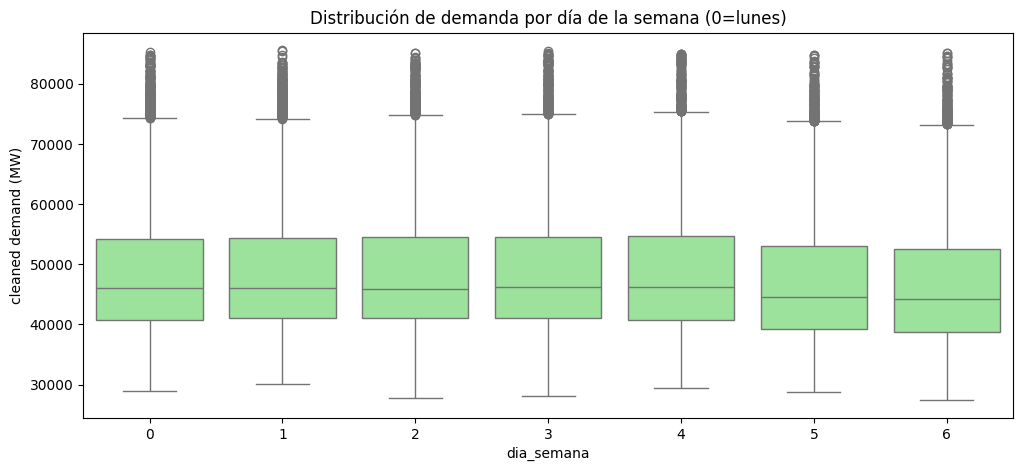

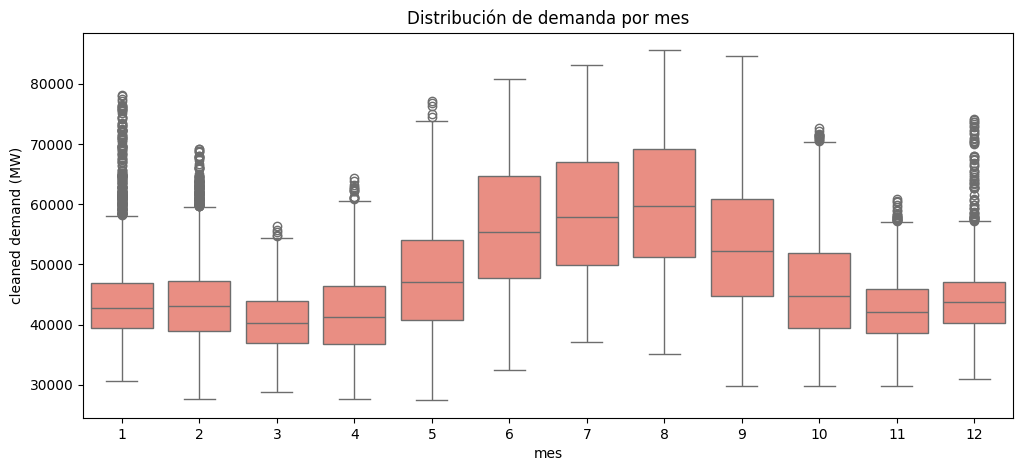

In [10]:
# Convertimos a hora local de Texas para que las etiquetas tengan sentido físico.
idx_local = df.index.tz_localize('UTC', ambiguous='NaT', nonexistent='NaT').tz_convert('America/Chicago')

df['hora_utc']   = df.index.hour            # como vienen los datos (UTC)
df['hora_local'] = idx_local.hour           # hora real de Texas
df['dia_semana'] = idx_local.dayofweek
df['mes']        = idx_local.month

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='hora_local', y='cleaned demand (MW)', color='skyblue')
plt.title('Distribución de demanda por hora del día (hora LOCAL de Texas)')
plt.xlabel('Hora local (America/Chicago)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='dia_semana', y='cleaned demand (MW)', color='lightgreen')
plt.title('Distribución de demanda por día de la semana (0=lunes)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='mes', y='cleaned demand (MW)', color='salmon')
plt.title('Distribución de demanda por mes')
plt.show()


## Ciclos observados (con números y en hora local)

- **Ciclo diario (en hora local de Texas):** pico alrededor de las **17 h (5 PM)** y valle
  hacia las **5 h (5 AM)**; en julio el pico es exactamente a las 17 h. La razón
  **pico/valle del perfil horario promedio es 1.37** (la demanda de la tarde es ~37 %
  mayor que la de la madrugada). *Nota: leído en UTC el pico aparece a las ~22 h por el
  desfase descrito arriba.*

- **Ciclo semanal:** los días **laborales** son ligeramente superiores a los **fines de
  semana** (~48,700 MW vs ~47,100 MW de media). El efecto existe pero es **modesto**
  comparado con los ciclos diario y anual.

- **Ciclo anual:** picos en **verano** (jun–ago), con **agosto** como mes de mayor
  demanda (mediana **~59,800 MW**) y **marzo** como el menor (mediana **~40,200 MW**).
  La brecha mediana verano–invierno es de **~19,600 MW**, una variación enorme.

**Decisiones de modelado derivadas:**
- Hay **estacionalidad múltiple** (diaria, semanal, anual). Para el modelo estadístico
  usar **SARIMA** con período estacional, o incorporar variables de calendario
  (hora, día de semana, mes) y términos de **Fourier** para las estacionalidades largas.
- Para la **LSTM**, la ventana de entrada debe cubrir al menos un ciclo diario completo
  (≥ 24 pasos) y conviene añadir features cíclicas (seno/coseno de hora y día).


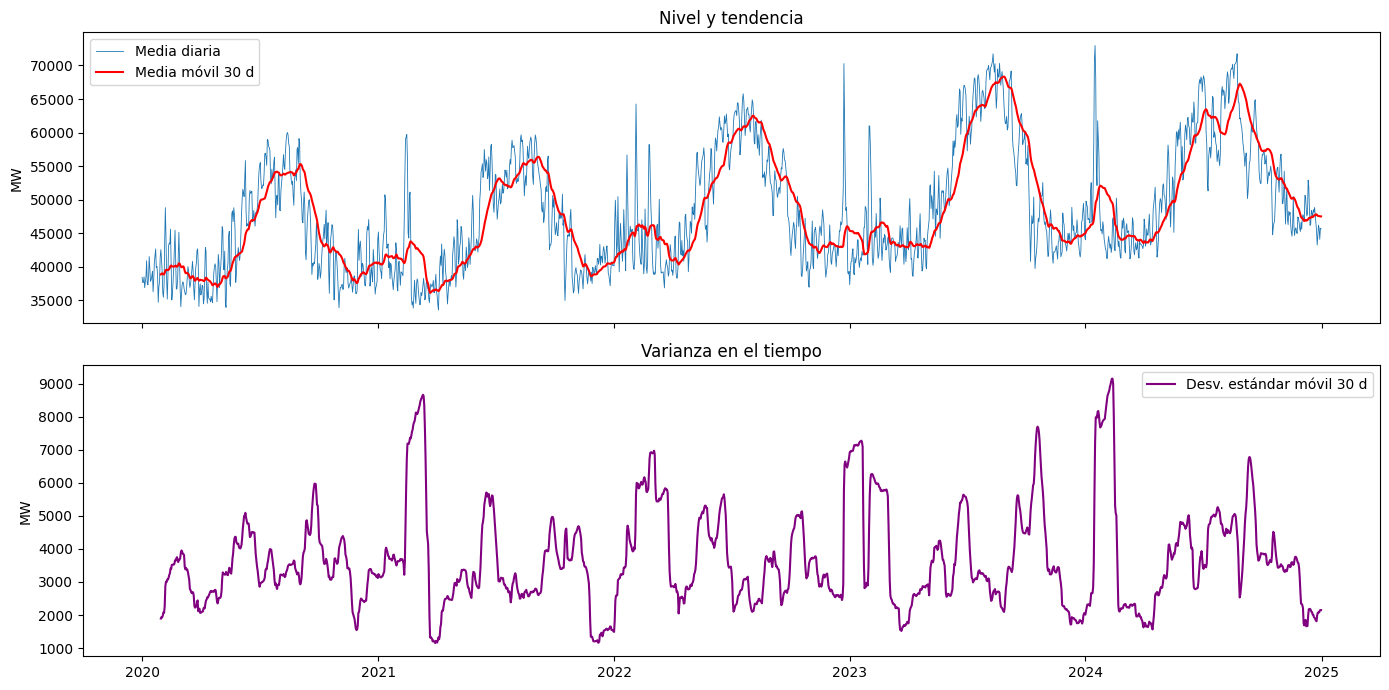

ADF sobre la serie horaria -> estadístico: -7.167 | p-valor: 0.0000
p < 0.05 => se rechaza H0 (estacionaria en sentido débil); aun así domina la fuerte estacionalidad anual.


In [11]:
# Punto 5 — Estacionariedad (supuesto central de ARIMA)
from statsmodels.tsa.stattools import adfuller

serie_dia = d.resample('D').mean()   # media diaria para ver tendencia/varianza con claridad

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].plot(serie_dia.index, serie_dia.values, linewidth=0.6, label='Media diaria')
ax[0].plot(serie_dia.rolling(30).mean(), color='red', label='Media móvil 30 d')
ax[0].set_ylabel('MW'); ax[0].legend(); ax[0].set_title('Nivel y tendencia')
ax[1].plot(serie_dia.rolling(30).std(), color='purple', label='Desv. estándar móvil 30 d')
ax[1].set_ylabel('MW'); ax[1].legend(); ax[1].set_title('Varianza en el tiempo')
plt.tight_layout(); plt.show()

# Prueba ADF (H0: la serie tiene raíz unitaria = NO estacionaria)
adf = adfuller(d.dropna(), autolag='AIC')
print(f'ADF sobre la serie horaria -> estadístico: {adf[0]:.3f} | p-valor: {adf[1]:.4f}')
print('p < 0.05 => se rechaza H0 (estacionaria en sentido débil); '
      'aun así domina la fuerte estacionalidad anual.')


### decisiones

La media móvil muestra una **fuerte oscilación estacional anual** (verano alto, invierno
bajo) y la desviación estándar móvil **no es constante**: la varianza es mayor en los meses
de verano (**heterocedasticidad estacional**). La serie horaria pasa la prueba ADF
(p < 0.05) por la masa de observaciones, pero eso **no elimina la estacionalidad**.

**Decisiones de modelado derivadas:**
- **ARIMA:** la serie **no es estacionaria en media estacional** → aplicar **diferenciación
  estacional** (p. ej. SARIMA con período diario/anual) y considerar transformación
  **log/Box-Cox** para la varianza creciente en verano. Verificar residuos con ACF/PACF.
- **LSTM:** no exige estacionariedad, pero el escalado y las features de calendario ayudan
  a que aprenda los ciclos sin tener que reconstruir la tendencia estacional desde cero.


## Resumen

| Hallazgo del EDA | Decisión de modelado |
|---|---|
| Timestamps en **UTC** (pico real 17 h local) | Fijar una zona horaria única; convertir antes de unir clima/temperatura para evitar desfase de 5–6 h |
| Distribución **sesgo derecho** (skew 0.92, curtosis 0.39) | log/Box-Cox para ARIMA; escalado (solo con train) para LSTM |
| **Estacionalidad múltiple** (diaria 1.37×, semanal leve, anual ~19,600 MW) | SARIMA / términos de Fourier; features de calendario y cíclicas; ventana LSTM ≥ 24 h |
| Serie **no estacionaria** en media/varianza estacional | Diferenciación estacional + transformación de varianza para ARIMA |
| **COVID** = −1.1 % (ruido) | No es choque estructural; 2020 va en train |
| **1.25 % (549 h) imputado**, máx 45,525 MW (ago-2024) | Bandera `es_imputado`; reportar si el test cae sobre horas imputadas |
| **Tarea: pronóstico a 24 h** | Define horizonte de evaluación (MAE/RMSE/MAPE a 24 h) y diseño walk-forward |


___

### Metodo de evaluacion reutilizable 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate(real, pred, name='Model', graficar=True):
    """
    Recibe predicciones + reales (series de pandas) y calcula MAE, RMSE y MAPE. y opcionalmente grafica predicciones vs reales.
    """

    real, pred = real.align(pred, join='inner')  # Alinea las series para que tengan el mismo índice
   
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = (np.abs((real - pred) / real)).mean() * 100

    print(f'{name} - MAE: {mae:,.0f} MW')
    print(f'{name} - RMSE: {rmse:,.0f} MW')
    print(f'{name} - MAPE: {mape:.2f} %')

    if graficar:
        plt.figure(figsize=(14,4))
        plt.plot(real.index, real.values, color='blue', linewidth=0.5, label='Real')
        plt.plot(pred.index, pred.values, color='orange', linewidth=0.5, label=name)
        plt.title(f'Predicción {name} vs Real (2024)')
        plt.xlabel('Fecha')
        plt.ylabel('Demanda (MW)')
        plt.legend()
        plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive Method (la predicción para el tiempo t es el valor observado en t-1)
df['prediction_naive'] = df['cleaned demand (MW)'].shift(1)

# Seasonal Naive (la predicción para el tiempo t es el valor observado en t-24h)
df['prediction_snaive_24h'] = df['cleaned demand (MW)'].shift(24)

df['prediction_snaive_168h'] = df['cleaned demand (MW)'].shift(168)  # 7 días atrás

eval_df = df.dropna(subset=['cleaned demand (MW)', 'prediction_naive', 'prediction_snaive_24h', 'prediction_snaive_168h'])


test = eval_df.loc['2024-01-01':'2024-12-31']

r_naive = evaluate(test['cleaned demand (MW)'], test['prediction_naive'], name='Naive Method')
r_snaive_24h = evaluate(test['cleaned demand (MW)'], test['prediction_snaive_24h'], name='Seasonal Naive 24h')
r_snaive_168h = evaluate(test['cleaned demand (MW)'], test['prediction_snaive_168h'], name='Seasonal Naive 168h')

MAE (Naive): 1,509 MW
RMSE (Naive): 1,870 MW
MAPE (Naive): 2.81 %
MAE (Seasonal Naive 24h): 2,359 MW
RMSE (Seasonal Naive 24h): 3,405 MW
MAPE (Seasonal Naive 24h): 4.51 %
MAE (Seasonal Naive 168h): 4,476 MW
RMSE (Seasonal Naive 168h): 6,265 MW
MAPE (Seasonal Naive 168h): 8.33 %


## Interpretación de los baselines

**La brecha RMSE > MAE**

En los tres modelos el RMSE supera al MAE (S-Naive 24h: **3,405 vs 2,359 MW**). Eso es esperado y nunca es negativo; lo informativo es **qué tan grande** es la separación. Una brecha amplia indica una distribución del error con **colas pesadas**: la mayoría de las horas se predicen razonablemente bien, pero hay horas con errores muy grandes —los cambios bruscos de demanda que vimos en el EDA (picos de verano, rampas de la tarde)— que el RMSE amplifica. Cuanto mayor la separación, más concentrado está el error en pocos momentos difíciles.

**El propósito: piso a vencer**

| Modelo | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Naive (t-1) | 1,509 | 1,870 | 2.81 |
| **Seasonal Naive 24h** | **2,359** | **3,405** | **4.51** |
| Seasonal Naive 168h | 4,476 | 6,265 | 8.33 |

El **Naive (t-1)** parece el mejor, pero es **engañoso**: copiar el valor de la hora anterior solo funciona a 1 paso y **no es un pronóstico real** para nuestra tarea. Al predecir las próximas 24 horas no disponemos del valor de t-1 (es justo lo que queremos estimar), así que ese 2.81 % es un número irreal para el horizonte que nos importa.

El **Seasonal Naive 168h** (una semana atrás) se degrada porque la demanda cambia más entre semanas —clima, estacionalidad anual— que entre días equivalentes.

El **Seasonal Naive 24h** aprovecha el fuerte ciclo diario de la demanda (cada hora se parece a la misma hora del día anterior, razón pico/valle 1.37 del EDA), está disponible en el horizonte de 24 h. **Su MAPE de ~4.5 % es el piso a vencer.** SARIMA y la LSTM deben quedar por debajo de ese error; si no lo logran, no están capturando nada que un simple "ayer a esta hora" no explique ya.

In [13]:
# Crear split (train 2020-2022, val 2023, test 2024)

fin_train = '2022-12-31 23:59:59'
fin_val   = '2023-12-31 23:59:59'


train = df.loc[:fin_train, 'cleaned demand (MW)']
val = df.loc[fin_train:fin_val, 'cleaned demand (MW)']
test = df.loc[fin_val:, 'cleaned demand (MW)']

print("Split de la serie:")
print(f"Train: {train.index.min()} a {train.index.max()} | Horas: {len(train)}")
print(f"Val:   {val.index.min()} a {val.index.max()}     | Horas: {len(val)}")
print(f"Test:  {test.index.min()} a {test.index.max()}     | Horas: {len(test)}")

Split de la serie:
Train: 2020-01-01 00:00:00 a 2022-12-31 23:00:00 | Horas: 26304
Val:   2023-01-01 00:00:00 a 2023-12-31 23:00:00     | Horas: 8760
Test:  2024-01-01 00:00:00 a 2024-12-31 23:00:00     | Horas: 8784


___

### Modelo Holt-Winters

MAE (Holt-Winters WF): 4,676 MW
RMSE (Holt-Winters WF): 6,670 MW
MAPE (Holt-Winters WF): 9.21 %


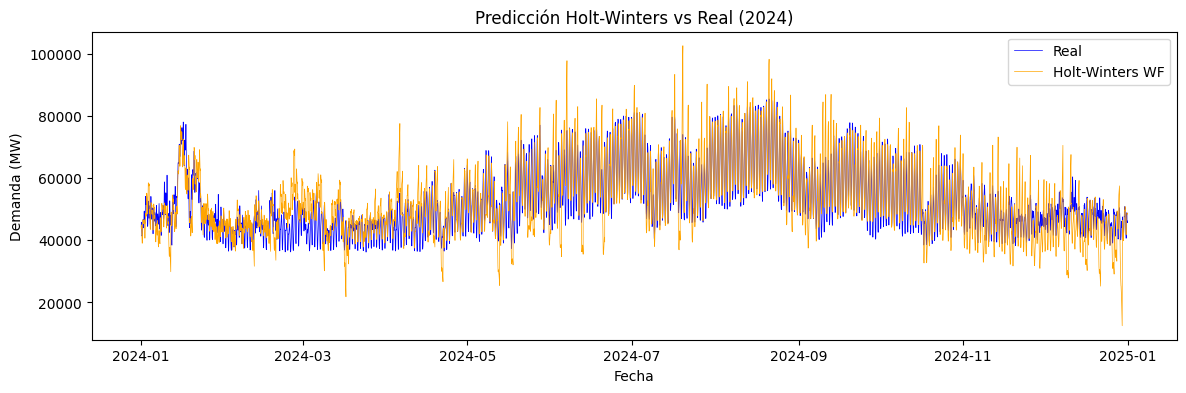

In [ ]:
# Ajustar un modelo holt-winters sobre el train 
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

serie = df['cleaned demand (MW)']

H = 24  # periodicidad diaria
ventana = 60*24 # periodicidad semanal

inicio_test = serie.index.get_loc('2024-01-01 00:00:00') 
fin_test = len(serie)

predicciones = []
indices = []

for origen in range(inicio_test, fin_test - H + 1, H):

    # 1) Datos para entrenar: SOLO lo anterior al 'origen' (esto evita la fuga)
    historia = serie.iloc[origen - ventana:origen]    # una ventana de tamaño VENTANA que TERMINA en 'origen'

    # 2) Ajustar Holt-Winters con esa historia
    modelo = ExponentialSmoothing(historia, trend='add', seasonal='mul', seasonal_periods=24).fit()

    # 3) Pronosticar las próximas H horas
    pred = modelo.forecast( H )   # ¿cuántos pasos? (NO len(test))

    # 4) Guardar las predicciones y las fechas a las que corresponden
    predicciones.extend(pred)
    indices.extend(serie.index[origen : origen + H])

# Juntar todo y calcular métricas (igual que antes)
pred_hw = pd.Series(predicciones, index=indices)
real    = serie.loc[pred_hw.index]

r_hw = evaluate(real, pred_hw, name='Holt-Winters WF')

# Comparación entre Holt-Winters y Seasonal Naive 

Se entreno un modelo de Holt-Winters con los mismos datos con un walk-forward de 24h  y se comparo con el Seasonal Naive 24h.

El modelo de Holt-Winters obtuvo un MAE de 4,676 MW y RMSE de 6,670 MW, mientras que el Seasonal Naive 24h obtuvo un MAE de 2,359 MW y RMSE de 3,405 MW. 

| Modelo | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Holt-Winters | 4,676 | 6,670 | 9.21 |
| **Seasonal Naive 24h** | **2,359** | **3,405** | **4.51** |

Aqui nos damos cuenta que el modelo de Holt-Winters no logra superar el piso tiene el doble de error y pierde en 11 de 12 meses (9.21% vs 4.51%), lo que indica que no está capturando mejor los patrones de la demanda que un simple modelo estacional.

### Entonces, ¿por qué un promedio pierde contra copiar el dato real reciente? 
El Seasonal Naive predice la hora de hoy copiando el valor real de ayer a esa misma hora. Pero ese valor no es solo un numero: carga la información de las condiciones de ayer — qué tan caluroso estuvo, si fue día laboral, el nivel general de demanda. Y como la demanda es muy persistente día a día (si ayer hizo calor y fue alta, hoy probablemente también), copiar ayer le da gratis el estado reciente.
Holt-Winters, en cambio, tira esa información a la basura: construye una forma diaria promedio sobre 60 días y la aplica. Promediar borra a propósito lo específico de cada día. Entonces, cualquier día que se desvíe del promedio de 60 días —que son casi todos, en algún grado— HW predice el promedio y le erra, mientras el naive sigue el estado real reciente. Eso es estructural y pasa siempre, por eso pierde hasta en los meses tranquilos. Tambien el período de 24 solo conoce el ciclo diario, no el semanal. Holt-Winters no tiene forma de representar "entre semana vs fin de semana" — cada sábado y domingo predice una forma de día laboral y le erra. Eso pasa 52 veces al año, siempre.

### ¿Descartas el suavizado exponencial? ¿Qué esperas de ARIMA, y por qué podría pelearle mejor al naive que Holt-Winters? 

El suavizado exponencial, como el modelo de Holt-Winters, es un método que asigna más peso a las observaciones recientes para capturar tendencias y estacionalidades. Sin embargo, en este caso específico de la demanda eléctrica en Texas, el modelo de Holt-Winters no logró superar el rendimiento del Seasonal Naive 24h, lo que sugiere que el suavizado exponencial puede no ser lo suficientemente flexible para capturar los patrones complejos de la demanda eléctrica.

ARIMA, por otro lado, es un modelo estadístico que puede capturar tanto la tendencia como la estacionalidad de una serie temporal, y también puede manejar la heterocedasticidad mediante transformaciones. ARIMA puede hacer lo mismo que el naive (apoyarse en el dato reciente) y además meterle estructura estacional. Esa es la razón por la que ARIMA podría pelearle al naive: no porque "siga mejor los eventos raros", sino porque no tira a la basura el estado reciente como hace HW

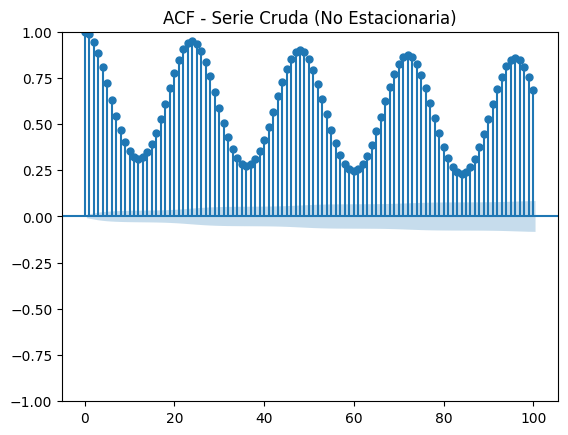

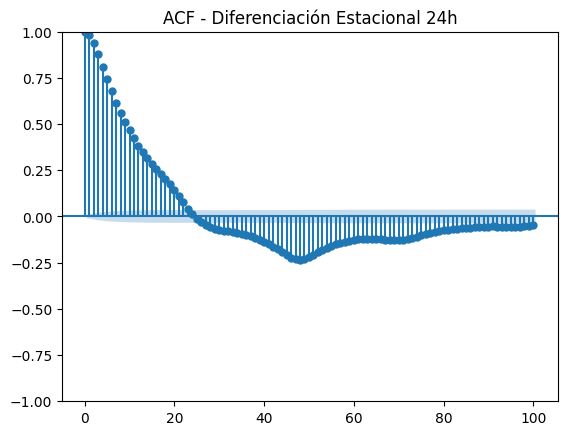

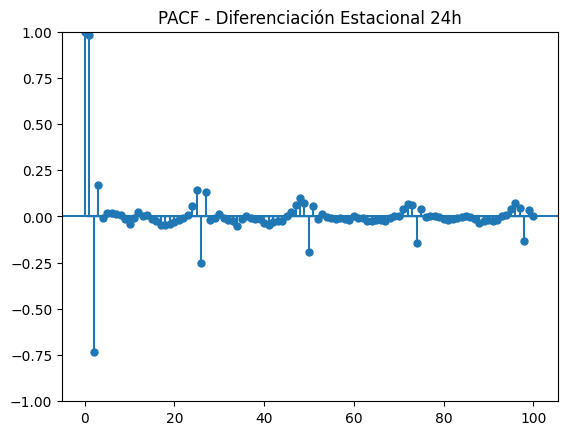

In [15]:
# Graficar el ACF

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['cleaned demand (MW)'], lags=100)
plt.title("ACF - Serie Cruda (No Estacionaria)")
plt.show()

# Aplicar diferenciación estacional (24h) para ver si se estaciona la serie

demanda_diff = df['cleaned demand (MW)'].diff(24).dropna()

plot_acf(demanda_diff, lags=100)
plt.title("ACF - Diferenciación Estacional 24h")
plt.show()

# Ahora graficar el PACF para ver si hay correlación parcial significativa

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(demanda_diff, lags=100)
plt.title("PACF - Diferenciación Estacional 24h")
plt.show()

Tras graficar el ACF y el PACF respectivos aplicando una diferenciacion estacional de 24h, tambien guiandonos por la regla de Box-Jenkins Toda la lectura de ACF/PACF se reduce a reconocer cuál de esas dos formas tiene cada una. La regla usada es esta:

![ACF diferenciada a 24](image/Screenshot_2026-06-24_at_2.52.57_p.m.-removebg-preview.png)

| Forma de la ACF | Forma de la PACF | Conclusión
|---|---:|---:|
| cola (decae gradual) | corte (cae de golpe tras lag p) | AR(p) — usa términos AR |
| corte (cae de golpe tras lag q) | cola (decae gradual) | MA(q) — usa términos MA |
| cola | cola | ARMA (mezcla de ambos) |
| muy lenta, casi no decae | - | no estacionaria → diferencia primero |

La ACF cruda oscila con picos en 24, 48, 72… que decaen lento. Eso es justo la última fila de la tabla: no estacionaria + estacionalidad diaria fuerte. Por eso diferenciaste a 24.

Una vez diferenciada a 24, la ACF decae gradualmente (cola) y la PACF se corta temprano. Esta combinación indica un **AR** de orden 2 con picos estacionales que sugieren ademas un componente AR estacional.

Los candidatos a comparar es entonces un **SARIMA(2,0,0)(1,1,0,24)**. El primer paréntesis es el ARMA no estacional (p=2, d=0, q=0) y el segundo paréntesis es el estacional (P=1, D=1, Q=0, s=24).


MAE (SARIMA): 2,164 MW
RMSE (SARIMA): 3,144 MW
MAPE (SARIMA): 4.18 %


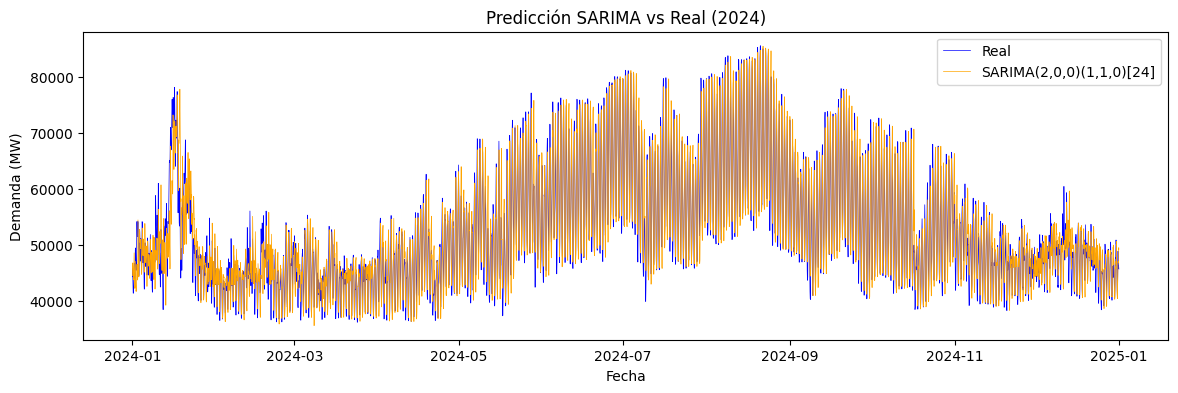

In [ ]:
# primero haz correr un solo SARIMA(2,0,0)(1,1,0)₂₄  

import statsmodels.api as sm

serie = df['cleaned demand (MW)']

H = 24  # periodicidad diaria
ventana = 60*24 # periodicidad semanal

inicio_test = serie.index.get_loc('2024-01-01 00:00:00') 
fin_test = len(serie)

predicciones = []
indices = []

for origen in range(inicio_test, fin_test - H + 1, H):

    # 1) Datos para entrenar: SOLO lo anterior al 'origen' (esto evita la fuga)
    historia = serie.iloc[origen - ventana:origen]    # una ventana de tamaño VENTANA que TERMINA en 'origen'

    # 2) Ajustar SARIMA con esa historia
    model = sm.tsa.SARIMAX(historia, order=(2, 0, 0), seasonal_order=(1, 1, 0, 24)).fit(disp=False)

    # 3) Pronosticar las próximas H horas
    pred = model.get_forecast(steps=H).predicted_mean

    # 4) Guardar las predicciones y las fechas a las que corresponden
    predicciones.extend(pred)
    indices.extend(serie.index[origen : origen + H])

# Juntar todo y calcular métricas (igual que antes)
pred_sm = pd.Series(predicciones, index=indices)
real    = serie.loc[pred_sm.index]

r_sm = evaluate(real, pred_sm, name='SARIMA(2,0,0)(1,1,0)24')

summary = pd.DataFrame([r_naive, r_snaive_24h, r_snaive_168h, r_hw, r_sm]).set_index(['Model'])
summary.round(2)